In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
data=pd.read_csv('1.netflix.csv')
data

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [6]:
data.info

<bound method DataFrame.info of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mab

In [7]:
data.shape

(8807, 12)

In [8]:
data.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [9]:
data['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [10]:
data['rating']=data['rating'].replace({'PG-13':'Teens(13+)','PG':'Older Kids(7+)','TV-MA':'Adults(18+)','TV-14':'Young Adults(16+)',
                           'TV-PG':'Older Kids(7+)Parental Guidance Suggested','TV-Y':'Kids(All)','TV-Y7':'Older Kids(7+)','R':'Adults only',
                           'NC-17':'No One 17 and Under Admitted', 'TV-G':'Kids(All)Suitable for all ages',
                           'TV-Y7-FV':'Older Kids(7+)programming with fantasy violence','NR':'Adults(18+) NotRated',
                           'G':'Kids(All)','UR':'Unrated'})
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,Teens(13+),90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,Adults(18+),2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,Adults(18+),1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,Adults(18+),1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,Adults(18+),2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [12]:
data['date_added'].value_counts()

date_added
January 1, 2020      109
November 1, 2019      89
March 1, 2018         75
December 31, 2019     74
October 1, 2018       71
                    ... 
November 4, 2017       1
August 5, 2015         1
December 6, 2018       1
March 9, 2016          1
January 11, 2020       1
Name: count, Length: 1767, dtype: int64

In [13]:
data['date_added']=pd.to_datetime(data['date_added'], errors='coerce')

In [14]:
data['date_added'].value_counts()

date_added
2020-01-01    109
2019-11-01     89
2018-03-01     75
2019-12-31     74
2018-10-01     71
             ... 
2017-11-04      1
2015-08-05      1
2018-12-06      1
2016-03-09      1
2020-01-11      1
Name: count, Length: 1699, dtype: int64

# 1.1st Show in Netflix

In [15]:
data.sort_values(by=['release_year']).head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4250,s4251,TV Show,Pioneers: First Women Filmmakers*,NaN,NaN,NaN,2018-12-30,1925,Young Adults(16+),1 Season,TV Shows,This collection restores films from women who ...


In [16]:
fs=data[data['release_year']==1925]
fs

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4250,s4251,TV Show,Pioneers: First Women Filmmakers*,NaN,NaN,NaN,2018-12-30,1925,Young Adults(16+),1 Season,TV Shows,This collection restores films from women who ...


# Last Show in Netflix

In [17]:
data.sort_values(by=['release_year']).tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,Adults(18+),1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,Adults(18+),1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
18,s19,Movie,Intrusion,Adam Salky,"Freida Pinto, Logan Marshall-Green, Robert Joh...",NaN,2021-09-22,2021,Young Adults(16+),94 min,Thrillers,After a deadly home invasion at a couple’s new...
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
68,s69,Movie,Schumacher,"Hanns-Bruno Kammertöns, Vanessa Nöcker, Michae...",Michael Schumacher,NaN,2021-09-15,2021,Young Adults(16+),113 min,"Documentaries, International Movies, Sports Mo...",Through exclusive interviews and archival foot...


In [18]:
ls=data.loc[(data['release_year']==2021)&(data['date_added']=='2021-9-15')]
ls

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
49,s50,TV Show,Castle and Castle,NaN,"Richard Mofe-Damijo, Dakore Akande, Bimbo Manu...",Nigeria,2021-09-15,2021,Adults(18+),2 Seasons,"International TV Shows, TV Dramas","A pair of high-powered, successful lawyers fin..."
55,s56,TV Show,Nailed It,NaN,"Nicole Byer, Jacques Torres",United States,2021-09-15,2021,Older Kids(7+)Parental Guidance Suggested,6 Seasons,Reality TV,Home bakers with a terrible track record take ...
64,s65,Movie,Nightbooks,David Yarovesky,"Winslow Fegley, Lidya Jewett, Krysten Ritter",NaN,2021-09-15,2021,Older Kids(7+)Parental Guidance Suggested,103 min,Children & Family Movies,Scary story fan Alex must tell a spine-tinglin...
65,s66,TV Show,Numberblocks,NaN,"Beth Chalmers, David Holt, Marcel McCalla, Ter...",United Kingdom,2021-09-15,2021,Kids(All),6 Seasons,Kids' TV,"In a place called Numberland, math adds up to ..."
68,s69,Movie,Schumacher,"Hanns-Bruno Kammertöns, Vanessa Nöcker, Michae...",Michael Schumacher,NaN,2021-09-15,2021,Young Adults(16+),113 min,"Documentaries, International Movies, Sports Mo...",Through exclusive interviews and archival foot...
70,s71,TV Show,Too Hot To Handle: Latino,NaN,Itatí Cantoral,NaN,2021-09-15,2021,Adults(18+),1 Season,"International TV Shows, Reality TV, Romantic T...","On this reality show, singles from Latin Ameri..."


In [19]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   str           
 1   type          8807 non-null   str           
 2   title         8807 non-null   str           
 3   director      6173 non-null   str           
 4   cast          7982 non-null   str           
 5   country       7976 non-null   str           
 6   date_added    8709 non-null   datetime64[us]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   str           
 9   duration      8804 non-null   str           
 10  listed_in     8807 non-null   str           
 11  description   8807 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 825.8 KB


In [20]:
data.describe()

,date_added,release_year
count,8709,8807.000000
mean,2019-05-23 01:45:29.452290,2014.180198
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-20 00:00:00,2013.000000
50%,2019-07-12 00:00:00,2017.000000
75%,2020-08-26 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


In [21]:
data.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        98
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

<Axes: >

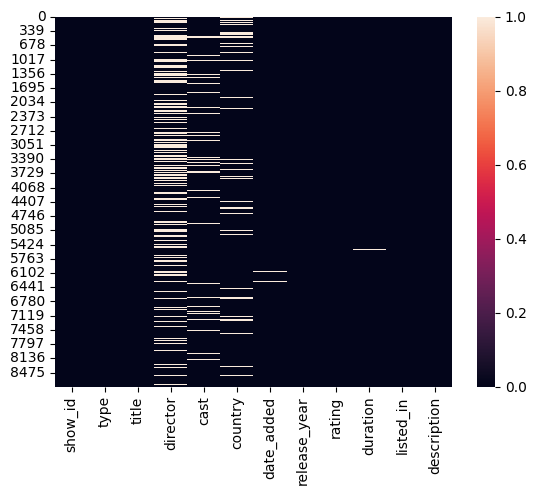

In [22]:
sns.heatmap(data.isnull())

In [23]:
data['rating'].unique()

<StringArray>
[                                     'Teens(13+)',
                                     'Adults(18+)',
                                  'Older Kids(7+)',
                               'Young Adults(16+)',
       'Older Kids(7+)Parental Guidance Suggested',
                                       'Kids(All)',
                                     'Adults only',
                  'Kids(All)Suitable for all ages',
                    'No One 17 and Under Admitted',
                                          '74 min',
                                          '84 min',
                                          '66 min',
                            'Adults(18+) NotRated',
                                               nan,
 'Older Kids(7+)programming with fantasy violence',
                                         'Unrated']
Length: 16, dtype: str

In [24]:

# check unique values (optional)
data['rating'].unique()

# remove wrong duration values from rating
data['rating'] = data['rating'].replace(
    ['74 min', '84 min', '66 min'],
    np.nan
)

# drop NaN ratings and reset index properly
data = data.dropna(subset=['rating']).reset_index(drop=True)

data.head()
# check unique values (optional)
data['rating'].unique()

# remove wrong duration values from rating
data['rating'] = data['rating'].replace(
    ['74 min', '84 min', '66 min'],
    np.nan
)

# drop NaN ratings and reset index properly
data = data.dropna(subset=['rating']).reset_index(drop=True)

data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens(13+),90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,Adults(18+),1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,Adults(18+),1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [25]:
data= data.dropna(subset=['duration']).reset_index()    

In [26]:
data['director']=data['director'].fillna('Unknown')
data['cast']=data['cast'].fillna('Unknown')

In [27]:
data.isnull().sum()

index             0
show_id           0
type              0
title             0
director          0
cast              0
country         830
date_added       98
release_year      0
rating            0
duration          0
listed_in         0
description       0
dtype: int64

In [28]:
data['country'] = data['country'].fillna(data['country'].mode()[0])
data['date_added'] = data['date_added'].fillna(data['date_added'].mode()[0])

In [29]:
data.isnull().sum()

index           0
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [30]:
data.duplicated().sum()

np.int64(0)

# 2.Which type of Shows released the most in Netflix

In [31]:
data['type'].value_counts()

type
Movie      6126
TV Show    2674
Name: count, dtype: int64

In [32]:
M=data[data['type']=='Movie']
M=M.sort_values(by='date_added',ascending=False).reset_index().drop('index',axis =1)
M.head()

,level_0,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,Teens(13+),90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,Teens(13+),104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
2,6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,Older Kids(7+),91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
3,7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,Adults(18+),125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
4,12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,Adults(18+),127 min,"Dramas, International Movies",After most of her family is murdered in a terr...


In [33]:
M = data[data['type'] == 'Movie']

M = (
    M.sort_values(by='date_added', ascending=False)
     .reset_index(drop=True)
)

M.head()


,index,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,Teens(13+),90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,Teens(13+),104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
2,6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,Older Kids(7+),91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
3,7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,Adults(18+),125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
4,12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,Adults(18+),127 min,"Dramas, International Movies",After most of her family is murdered in a terr...


In [34]:
T = data[data['type'] == 'TV Show']

T = (
    T.sort_values(by='date_added', ascending=False)
     .reset_index(drop=True)
)

T.head()

,index,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
1,5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,2021-09-24,2021,Adults(18+),1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
2,10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",Unknown,Unknown,United States,2021-09-24,2021,Adults(18+),1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
3,8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,Young Adults(16+),9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
4,2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,Adults(18+),1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [35]:
T.describe(include='object')

,show_id,type,title,director,cast,country,rating,duration,listed_in,description
count,2674,2674,2674,2674,2674,2674,2674,2674,2674,2674
unique,2674,1,2674,223,2282,196,9,15,236,2670
top,s2,TV Show,Blood & Water,Unknown,Unknown,United States,Adults(18+),1 Season,Kids' TV,Born into a small town controlled by the mafia...
freq,1,2674,1,2444,350,1151,1145,1791,220,2


In [36]:
data['type'].value_counts()

type
Movie      6126
TV Show    2674
Name: count, dtype: int64

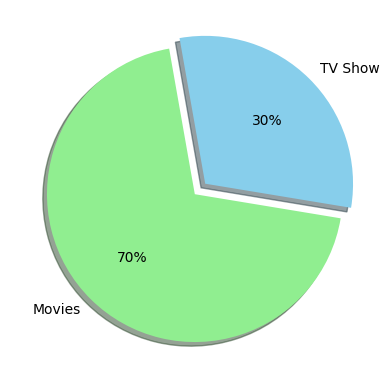

In [37]:
plt.pie(data['type'].value_counts(),labels=['Movies','TV Show'],explode=(0,0.1),startangle=100,shadow=True,autopct='%.0f%%',colors=['lightgreen','skyblue'])
plt.show()

In [38]:
data['country'].unique()

<StringArray>
[                                                        'United States',
                                                          'South Africa',
                                                                 'India',
 'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia',
                                                        'United Kingdom',
                                               'Germany, Czech Republic',
                                                                'Mexico',
                                                                'Turkey',
                                                             'Australia',
                                          'United States, India, France',
 ...
                        'Germany, United States, United Kingdom, Canada',
          'Canada, India, Thailand, United States, United Arab Emirates',
                             'United States, East Germany, West Germany',
                   

In [39]:
df= data.copy()

In [40]:
df.value_counts()

index  show_id  type     title                  director         cast                                                                                                                                                                                                                                                                                                             country        date_added  release_year  rating             duration   listed_in                                                      description                                                                                                                                             
0      s1       Movie    Dick Johnson Is Dead   Kirsten Johnson  Unknown                                                                                                                                                                                                                                                                               

In [41]:
df['country'].value_counts()

country
United States                                    3645
India                                             972
United Kingdom                                    419
Japan                                             244
South Korea                                       199
                                                 ... 
Russia, Spain                                       1
Croatia, Slovenia, Serbia, Montenegro               1
Japan, Canada                                       1
United States, France, South Korea, Indonesia       1
United Arab Emirates, Jordan                        1
Name: count, Length: 748, dtype: int64

In [42]:
df['country'] =df['country'].str.split(',')

In [43]:
df['country'].value_counts()

country
[United States]                                       3645
[India]                                                972
[United Kingdom]                                       419
[Japan]                                                244
[South Korea]                                          199
                                                      ... 
[Russia,  Spain]                                         1
[Croatia,  Slovenia,  Serbia,  Montenegro]               1
[Japan,  Canada]                                         1
[United States,  France,  South Korea,  Indonesia]       1
[United Arab Emirates,  Jordan]                          1
Name: count, Length: 748, dtype: int64

In [44]:
df = df.explode('country')

In [45]:
df['country'].value_counts()

country
United States     4038
India             1008
United Kingdom     628
 United States     479
Canada             271
                  ... 
 Panama              1
 Namibia             1
 Uganda              1
 East Germany        1
 Montenegro          1
Name: count, Length: 197, dtype: int64

In [46]:
#remove leading spaces
df['country']=df['country'].str.strip()

In [47]:
df['country'].value_counts()

country
United States     4517
India             1046
United Kingdom     806
Canada             445
France             393
                  ... 
Sudan                1
Panama               1
Uganda               1
East Germany         1
Montenegro           1
Name: count, Length: 123, dtype: int64

In [48]:
df['country'].replace('',np.nan, inplace=True)

0       United States
1        South Africa
2       United States
3       United States
4               India
            ...      
8795    United States
8796    United States
8797    United States
8798    United States
8799            India
Name: country, Length: 10843, dtype: str

In [49]:
df['country'].value_counts()

country
United States     4517
India             1046
United Kingdom     806
Canada             445
France             393
                  ... 
Sudan                1
Panama               1
Uganda               1
East Germany         1
Montenegro           1
Name: count, Length: 123, dtype: int64

In [50]:
df.dropna(subset=['country'], inplace=True)

In [51]:
df.head()

,index,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,Teens(13+),90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,Adults(18+),1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021-09-24,2021,Adults(18+),1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [52]:
c = df["country"].value_counts()

In [53]:
top_c = c.idxmax()
top_co = c.max()

print(f"The country with the most Netflix shows is {top_c} ({top_co} titles).")

The country with the most Netflix shows is United States (4517 titles).


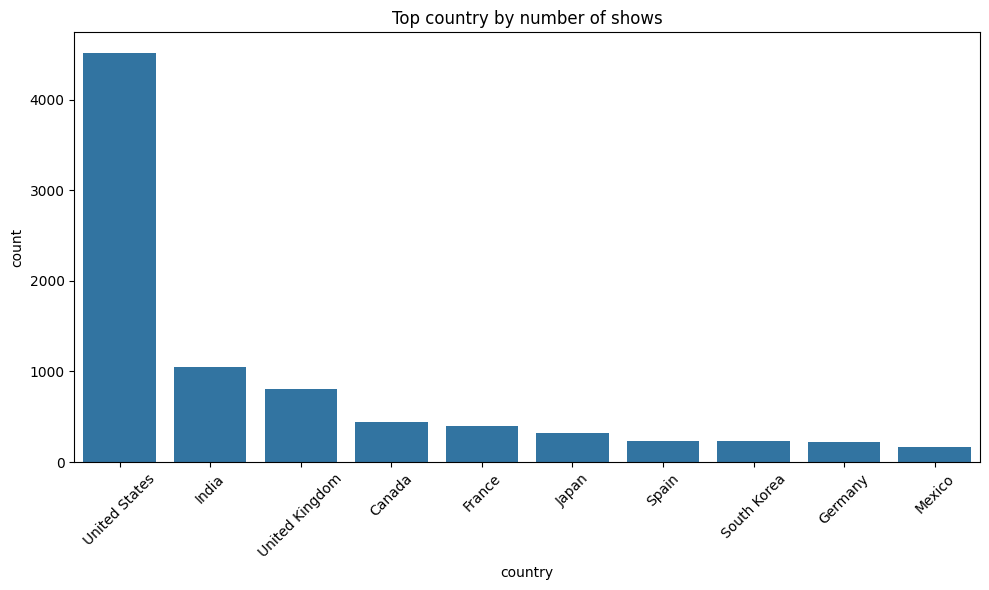

In [54]:
df = df.reset_index(drop=True)
plt.figure(figsize=(10,6))

top10= df ['country'].value_counts().head(10)

sns.countplot(
    data=df,
    x ='country',
    order=top10.index
)
plt.xticks(rotation=45)
plt.title('Top country by number of shows')
plt.xlabel('country')
plt.ylabel('count')
plt.tight_layout()
plt.show()

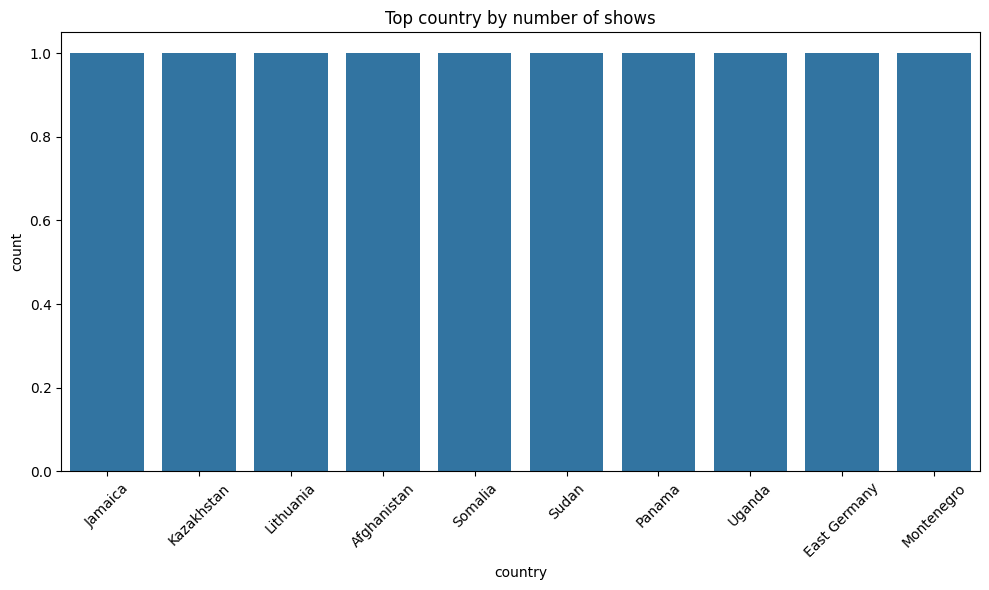

In [55]:
df = df.reset_index(drop=True)
plt.figure(figsize=(10,6))

bt= df ['country'].value_counts()

sns.countplot(
    data=df,
    x ='country',
    order=bt.index[-10:]
)
plt.xticks(rotation=45)
plt.title('Top country by number of shows')
plt.xlabel('country')
plt.ylabel('count')
plt.tight_layout()
plt.show()

# 4.which genre is released the most in netflix

In [56]:
data['listed_in'].value_counts()

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
                                                   ... 
Comedies, Cult Movies, LGBTQ Movies                   1
Action & Adventure, Comedies, Horror Movies           1
Classic & Cult TV, Crime TV Shows, TV Dramas          1
Action & Adventure, Documentaries, Sports Movies      1
Cult Movies, Dramas, Thrillers                        1
Name: count, Length: 514, dtype: int64

In [57]:
ds=data.copy()

In [58]:
ds['listed_in'] = ds['listed_in'].str.split(',')

In [59]:
ds=ds.explode('listed_in')

In [60]:
ds['listed_in'] = ds['listed_in'].str.strip()

In [61]:
ds['listed_in'].replace('',np.nan,inplace=True)

0                  Documentaries
1         International TV Shows
1                      TV Dramas
1                   TV Mysteries
2                 Crime TV Shows
                  ...           
8798    Children & Family Movies
8798                    Comedies
8799                      Dramas
8799        International Movies
8799            Music & Musicals
Name: listed_in, Length: 19314, dtype: str

In [62]:
ds.dropna(subset=['listed_in'],inplace=True)

In [63]:
ds=ds.reset_index(drop=True)

In [64]:
ds.head()

,index,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,Teens(13+),90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults(18+),2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t..."
2,1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults(18+),2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t..."
3,1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults(18+),2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t..."
4,2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,Adults(18+),1 Season,Crime TV Shows,To protect his family from a powerful drug lor...


In [65]:
ds['listed_in'].nunique()

42

In [66]:
ds['listed_in'].value_counts()

listed_in
International Movies            2752
Dramas                          2426
Comedies                        1674
International TV Shows          1350
Documentaries                    869
Action & Adventure               859
TV Dramas                        763
Independent Movies               756
Children & Family Movies         641
Romantic Movies                  616
TV Comedies                      580
Thrillers                        577
Crime TV Shows                   470
Kids' TV                         450
Docuseries                       395
Music & Musicals                 375
Romantic TV Shows                370
Horror Movies                    357
Stand-Up Comedy                  343
Reality TV                       255
British TV Shows                 253
Sci-Fi & Fantasy                 243
Sports Movies                    219
Anime Series                     175
Spanish-Language TV Shows        174
TV Action & Adventure            168
Korean TV Shows             

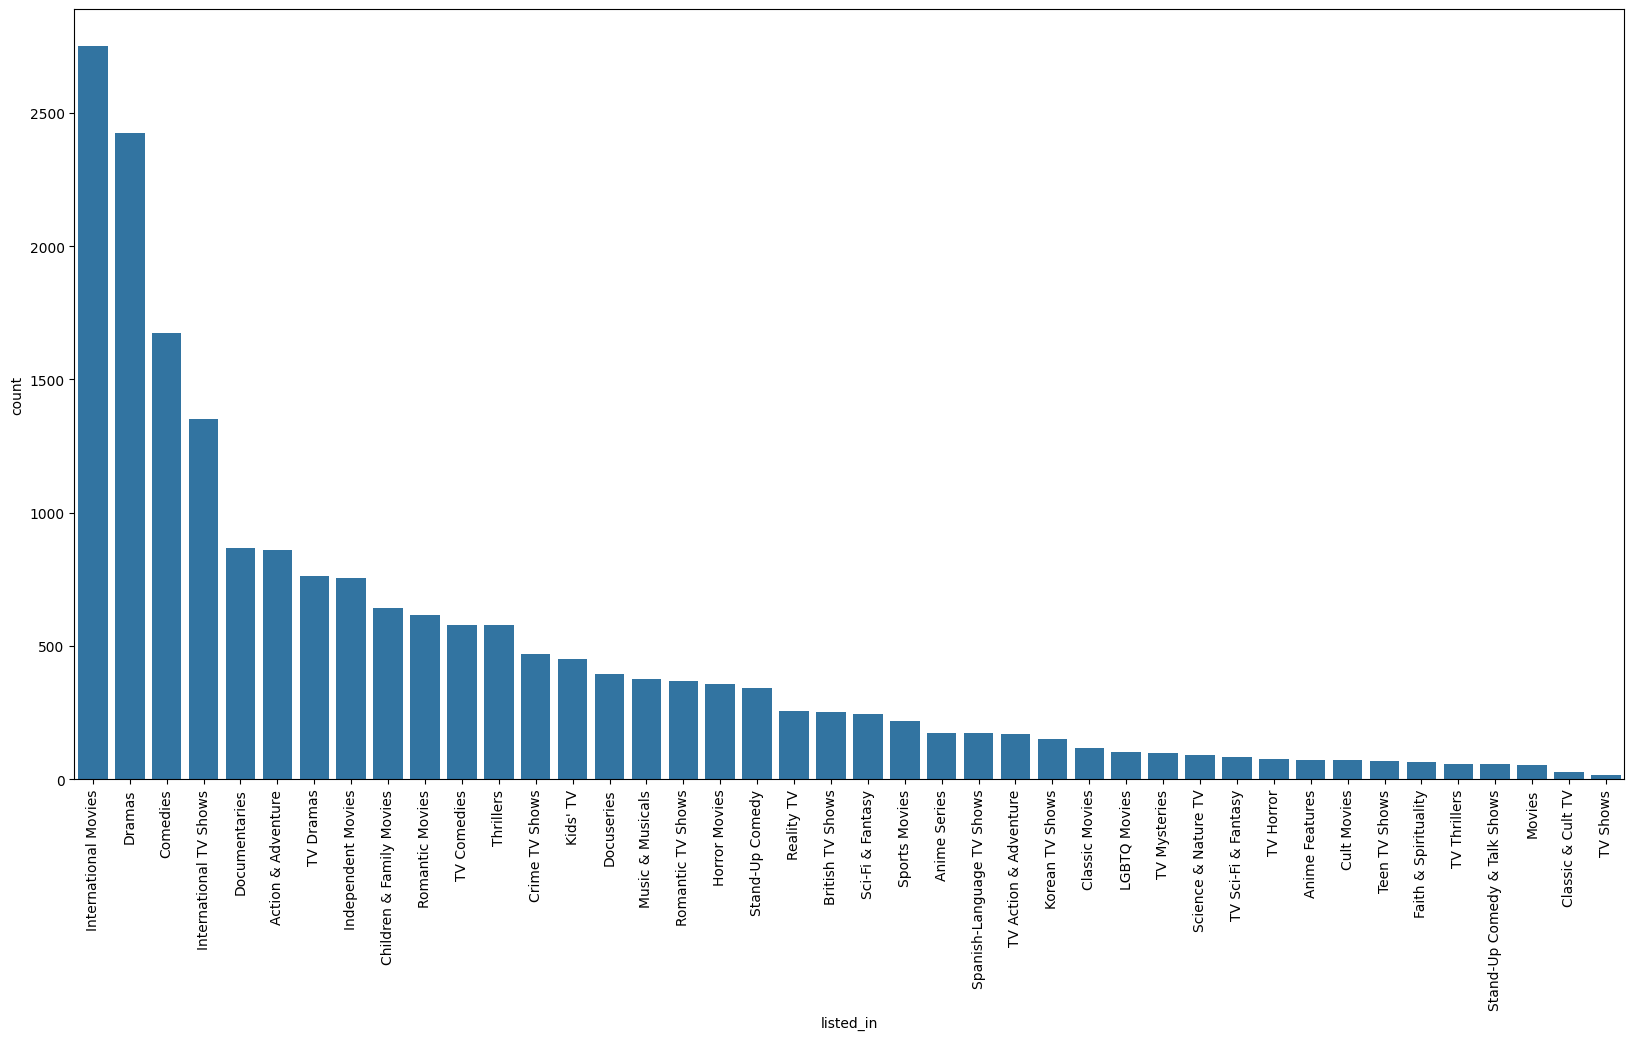

In [67]:
plt.figure(figsize=(20,10))
set=sns.countplot(x=ds['listed_in'],order=ds['listed_in'].value_counts(ascending=False).index)
set.set_xticklabels(set.get_xticklabels(),rotation=90)
plt.show()

# 5.which category has the most released show

In [68]:
data.groupby('rating')['title'].count().sort_values(ascending=False)

rating
Adults(18+)                                        3207
Young Adults(16+)                                  2160
Older Kids(7+)Parental Guidance Suggested           863
Adults only                                         799
Older Kids(7+)                                      621
Teens(13+)                                          490
Kids(All)                                           348
Kids(All)Suitable for all ages                      220
Adults(18+) NotRated                                 80
Older Kids(7+)programming with fantasy violence       6
No One 17 and Under Admitted                          3
Unrated                                               3
Name: title, dtype: int64

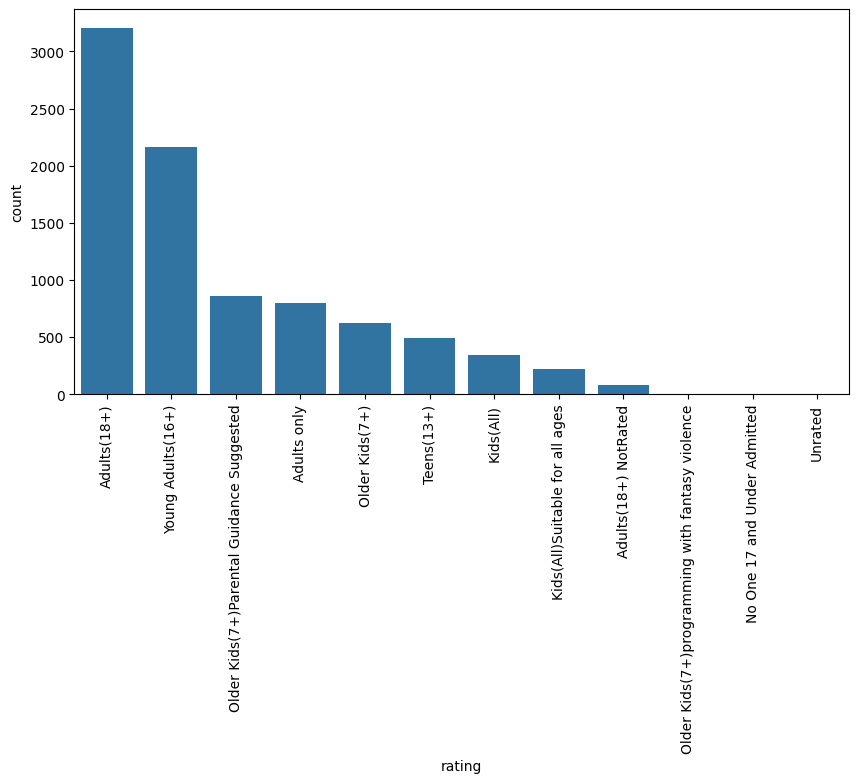

In [69]:
plt.figure(figsize=(10,5))
chart=sns.countplot(x='rating',data=data,order=data['rating'].value_counts(ascending=False).index[:12])
chart.set_xticklabels(chart.get_xticklabels(),rotation=90)
plt.show()

# 6.which director produced more work in netflix

In [70]:
dg=data.copy()

In [71]:
df.columns

Index(['index', 'show_id', 'type', 'title', 'director', 'cast', 'country',
       'date_added', 'release_year', 'rating', 'duration', 'listed_in',
       'description'],
      dtype='str')

In [72]:
dg['director'] = dg['director'].str.split(',')
dg = dg.explode('director')
dg['director'] = dg['director'].str.strip()
dg['director'] = dg['director'].replace('', np.nan)
dg.dropna(subset=['director'], inplace=True)
dg = dg.reset_index(drop=True)
dg['director'].value_counts().head(10)
dg

,index,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,Teens(13+),90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,Adults(18+),1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021-09-24,2021,Adults(18+),1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9600,8795,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,Adults only,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
9601,8796,s8804,TV Show,Zombie Dumb,Unknown,Unknown,United States,2019-07-01,2018,Older Kids(7+),2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
9602,8797,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,Adults only,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
9603,8798,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,Older Kids(7+),88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


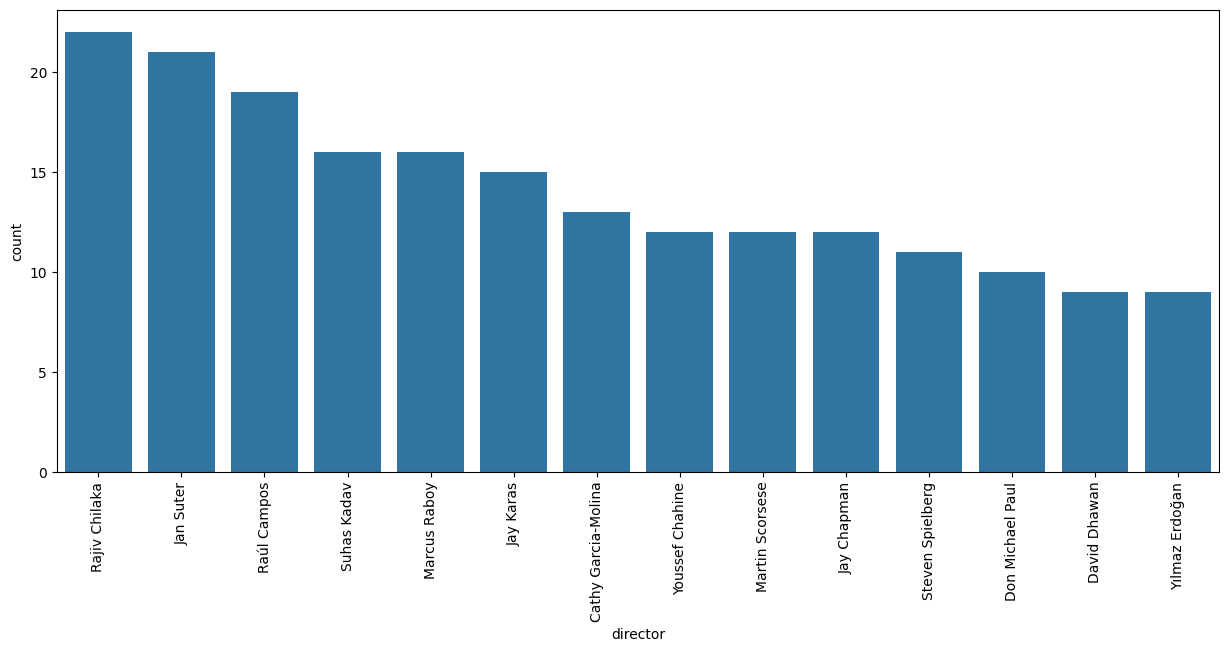

In [73]:
plt.figure(figsize=(15,6))
dr=sns.countplot(x='director',data=dg,order=dg['director'].value_counts(ascending=False).index[1:15])
dr.set_xticklabels(dr.get_xticklabels(),rotation=90)
plt.show()

# 7.Top 10 directors of TV show

In [74]:
t=(T.assign(director=T['director'].str.split(',')).explode('director'))
#remove extra spaces
t['director']=t['director'].str.strip()
#Replace empty string with Nan
t['director'].replace('',np.nan,inplace=True)
t.dropna(subset=['director'],inplace=True)
t.head()

,index,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
1,5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,2021-09-24,2021,Adults(18+),1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
2,10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",Unknown,Unknown,United States,2021-09-24,2021,Adults(18+),1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
3,8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,Young Adults(16+),9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
4,2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,Adults(18+),1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [75]:
t['director'].nunique()

300

In [76]:
t['director'].value_counts()

director
Unknown                  2444
Ken Burns                   3
Alastair Fothergill         3
Gautham Vasudev Menon       2
Hsu Fu-chun                 2
                         ... 
David Schalko               1
Toby Haynes                 1
Tensai Okamura              1
Eli Roth                    1
Stuart Orme                 1
Name: count, Length: 300, dtype: int64

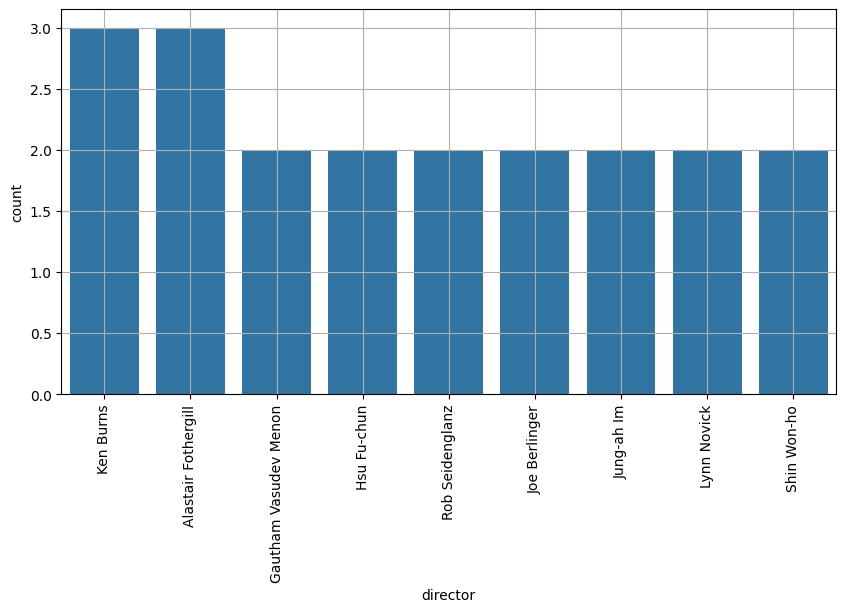

In [77]:
top_10_directors = t['director'].value_counts().nlargest(10).index[1:]

#filter the datafrrame to include only the rows with top 10 directors

filtterd_data = t[t['director'].isin(top_10_directors)]

#create the countplot

plt.figure(figsize=(10,5))
sns.countplot(x='director', data=filtterd_data,order=top_10_directors)

#rotate x axis labels for better readability
plt.xticks(rotation=90)

#display the grid 
plt.grid(True)
plt.show()

# 8.Who is the director who has directed the most tv show in india

In [78]:
do=(
    t.assign(country=t['country'].str.split(','))
    .explode('country')
)

do['country'] = do['country'].str.strip()

do.head()

,index,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
1,5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,2021-09-24,2021,Adults(18+),1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
2,10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",Unknown,Unknown,United States,2021-09-24,2021,Adults(18+),1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
3,8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,Young Adults(16+),9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
4,2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,Adults(18+),1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [79]:
bh=do[do['country']=='India']
bh.reset_index(drop=True, inplace=True)
bh.head()

,index,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
1,39,s40,TV Show,Chhota Bheem,Unknown,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",India,2021-09-16,2021,Older Kids(7+),3 Seasons,Kids' TV,"A brave, energetic little boy with superhuman ..."
2,66,s67,TV Show,Raja Rasoi Aur Anya Kahaniyan,Unknown,Unknown,India,2021-09-15,2014,Kids(All)Suitable for all ages,1 Season,"Docuseries, International TV Shows",Explore the history and flavors of regional In...
3,69,s70,TV Show,Stories by Rabindranath Tagore,Unknown,Unknown,India,2021-09-15,2015,Older Kids(7+)Parental Guidance Suggested,1 Season,"International TV Shows, TV Dramas",The writings of Nobel Prize winner Rabindranat...
4,50,s51,TV Show,Dharmakshetra,Unknown,"Kashmira Irani, Chandan Anand, Dinesh Mehta, A...",India,2021-09-15,2014,Older Kids(7+)Parental Guidance Suggested,1 Season,"International TV Shows, TV Dramas, TV Sci-Fi &...","After the ancient Great War, the god Chitragup..."


In [80]:
bh.groupby('director')['title'].count().sort_values(ascending=False)

director
Unknown                      73
Gautham Vasudev Menon         2
B. V. Nandini Reddy           1
Anurag Kashyap                1
Bumpy                         1
Caroline Sá                   1
Chico Pereira                 1
Arvind Swamy                  1
Deepti Kakkar                 1
Dheeraj Berry                 1
Elaine McMillion Sheldon      1
Fahad Mustafa                 1
Hikaru Toda                   1
Karthik Narain                1
Karthik Subbaraj              1
Bejoy Nambiar                 1
Moyoung Jin                   1
Nag Ashwin                    1
Patrick Graham                1
Nizar Shafi                   1
Rathindran R Prasad           1
Sankalp Reddy                 1
Sarjun                        1
Priyadarshan                  1
Soumendra Padhi               1
Sudha Kongara                 1
Tharun Bhascker Dhaassyam     1
Vasanth Sai                   1
Vetri Maaran                  1
Vignesh Shivan                1
Vijay Roche                   1

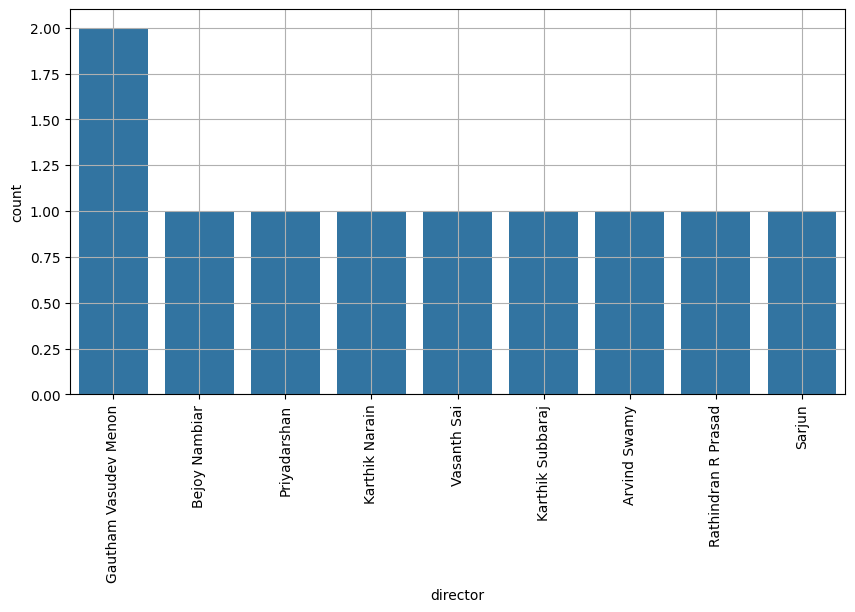

In [81]:
top_10_dir=bh['director'].value_counts().nlargest(10).index[1:]
filt_data=bh[bh['director'].isin(top_10_dir)]
plt.figure(figsize=(10,5))
sns.countplot(x='director',data=filt_data,order=top_10_dir)
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

# 7a.Top 10 directors of Movie

In [82]:
m=(M.assign(director=M['director'].str.split(',')).explode('director'))
#remove extra spaces
m['director']=m['director'].str.strip()
#Replace empty string with Nan
m['director'].replace('',np.nan,inplace=True)
m.dropna(subset=['director'],inplace=True)
m.head()

,index,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,Teens(13+),90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,Teens(13+),104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
2,6,s7,Movie,My Little Pony: A New Generation,Robert Cullen,"Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,Older Kids(7+),91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
2,6,s7,Movie,My Little Pony: A New Generation,José Luis Ucha,"Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,Older Kids(7+),91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
3,7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,Adults(18+),125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."


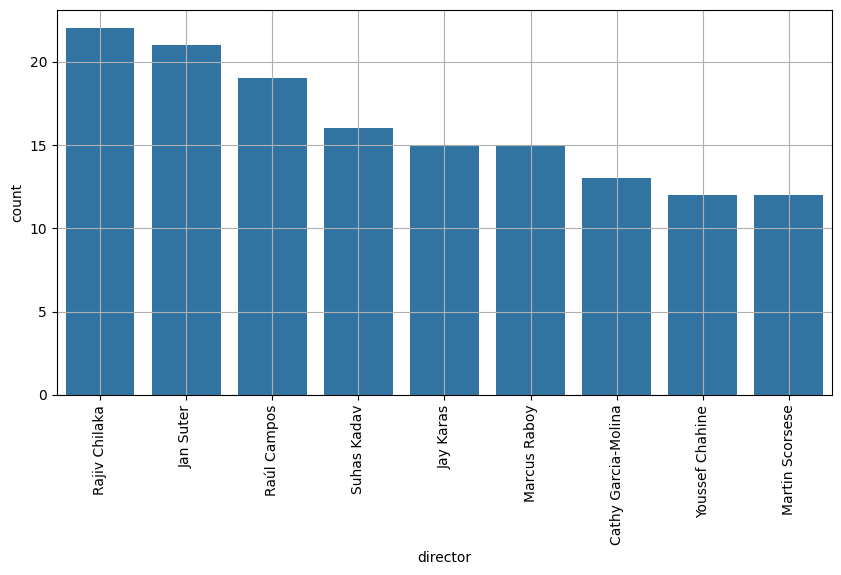

In [83]:
top_10_directors = m['director'].value_counts().nlargest(10).index[1:]

#filter the datafrrame to include only the rows with top 10 directors

filtterd_data = m[m['director'].isin(top_10_directors)]

#create the countplot

plt.figure(figsize=(10,5))
sns.countplot(x='director', data=filtterd_data,order=top_10_directors)

#rotate x axis labels for better readability
plt.xticks(rotation=90)

#display the grid 
plt.grid(True)
plt.show()

# 8a.Who is the director who has directed the Movie in india

In [84]:
do=(
    m.assign(country=m['country'].str.split(','))
    .explode('country')
)

do['country'] = do['country'].str.strip()

do.head()

,index,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,Teens(13+),90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,Teens(13+),104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
2,6,s7,Movie,My Little Pony: A New Generation,Robert Cullen,"Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,Older Kids(7+),91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
2,6,s7,Movie,My Little Pony: A New Generation,José Luis Ucha,"Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,Older Kids(7+),91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
3,7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",United States,2021-09-24,1993,Adults(18+),125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."


In [85]:
bh=do[do['country']=='India']
bh.reset_index(drop=True, inplace=True)
bh.head()

,index,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,2021-09-21,1998,Young Adults(16+),166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
1,29,s30,Movie,Paranoia,Robert Luketic,"Liam Hemsworth, Gary Oldman, Amber Heard, Harr...",India,2021-09-19,2013,Teens(13+),106 min,Thrillers,"Blackmailed by his company's CEO, a low-level ..."
2,105,s106,Movie,Angamaly Diaries,Lijo Jose Pellissery,"Antony Varghese, Reshma Rajan, Binny Rinky Ben...",India,2021-09-05,2017,Young Adults(16+),128 min,"Action & Adventure, Comedies, Dramas",After growing up amidst the gang wars of his h...
3,118,s119,Movie,Gurgaon,Shanker Raman,"Akshay Oberoi, Pankaj Tripathi, Ragini Khanna,...",India,2021-09-02,2017,Young Adults(16+),106 min,"Dramas, International Movies, Thrillers",When the daughter of a wealthy family returns ...
4,126,s127,Movie,Shikara,Vidhu Vinod Chopra,"Aadil Khan, Sadia Khateeb, Zain Khan Durrani, ...",India,2021-09-02,2020,Young Adults(16+),115 min,"Dramas, International Movies, Romantic Movies",A couple must strive to remain resilient after...


In [86]:
bh.groupby('director')['title'].count().sort_values(ascending=False)

director
Unknown            12
David Dhawan        9
Umesh Mehra         8
Anurag Kashyap      8
Ram Gopal Varma     7
                   ..
Vivek Agnihotri     1
Vivek Wagh          1
Vrinda Samartha     1
Zakariya            1
Vineeth Anil        1
Name: title, Length: 713, dtype: int64

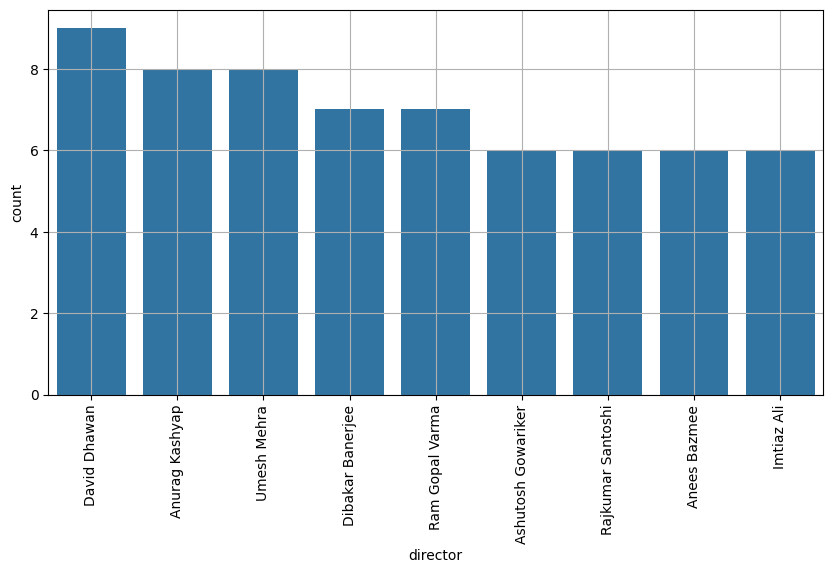

In [87]:
top_10_dir=bh['director'].value_counts().nlargest(10).index[1:]
filt_data=bh[bh['director'].isin(top_10_dir)]
plt.figure(figsize=(10,5))
sns.countplot(x='director',data=filt_data,order=top_10_dir)
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

# 9.Relation of year and rating in  a period of time

In [88]:
first=M[(M['release_year']>=1959)&(M['release_year']<=1979)]
first.reset_index(drop=True,inplace=True)
first.head()                                            

,index,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,41,s42,Movie,Jaws,Steven Spielberg,"Roy Scheider, Robert Shaw, Richard Dreyfuss, L...",United States,2021-09-16,1975,Older Kids(7+),124 min,"Action & Adventure, Classic Movies, Dramas",When an insatiable great white shark terrorize...
1,42,s43,Movie,Jaws 2,Jeannot Szwarc,"Roy Scheider, Lorraine Gary, Murray Hamilton, ...",United States,2021-09-16,1978,Older Kids(7+),116 min,"Dramas, Horror Movies, Thrillers",Four years after the last deadly shark attacks...
2,177,s178,Movie,The Guns of Navarone,J. Lee Thompson,"Gregory Peck, David Niven, Anthony Quinn, Stan...","United Kingdom, United States",2021-09-01,1961,Young Adults(16+),156 min,"Action & Adventure, Classic Movies","During World War II, British forces launch an ..."
3,542,s543,Movie,Ujala,Naresh Saigal,"Mala Sinha, Shammi Kapoor, Raaj Kumar, Leela C...",India,2021-07-06,1959,Young Adults(16+),143 min,"Dramas, International Movies",An honest man dreams of a better life for his ...
4,529,s530,Movie,Return of the Prodigal Son,Youssef Chahine,"Majida El Roumi, Souheir El Morshidy, Shoukry ...",Egypt,2021-07-06,1976,Adults(18+),124 min,"Dramas, International Movies","Freed after spending 12 years in jail, a man's..."


In [89]:
first.rating.value_counts()

rating
Young Adults(16+)                            21
Adults only                                  15
Older Kids(7+)Parental Guidance Suggested    15
Older Kids(7+)                               13
Adults(18+)                                  13
Kids(All)                                     7
Teens(13+)                                    3
Unrated                                       1
Kids(All)Suitable for all ages                1
Adults(18+) NotRated                          1
Name: count, dtype: int64

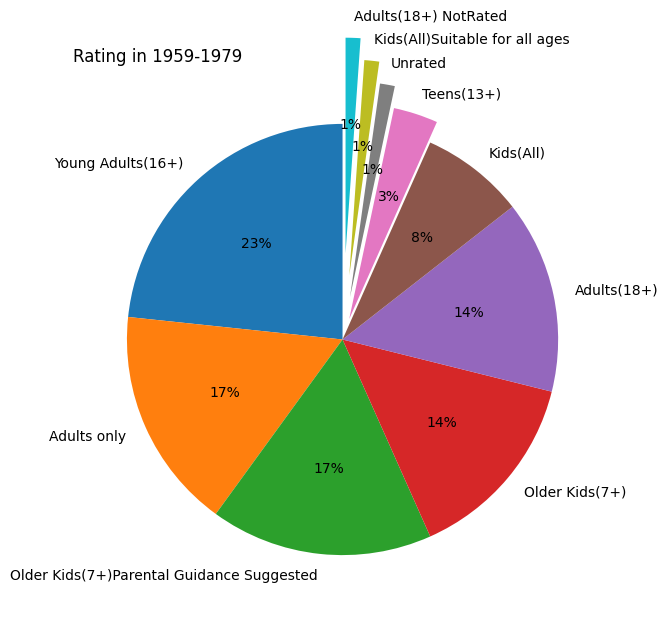

In [90]:
plt.figure(figsize=(7,7))
first.rating.value_counts().plot.pie(explode=(0,0,0,0,0,0,0.1,0.2,0.3,0.4),startangle=90,autopct='%.0f%%')
plt.title('Rating in 1959-1979',loc='left')
plt.show()

In [91]:
second=M[(M['release_year']>=1980)&(M['release_year']<=2000)]
second.reset_index(drop=True,inplace=True)
second.head()   

,index,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,Adults(18+),125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
1,22,s23,Movie,Avvai Shanmughi,K.S. Ravikumar,"Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...",United States,2021-09-21,1996,Older Kids(7+)Parental Guidance Suggested,161 min,"Comedies, International Movies",Newly divorced and denied visitation rights wi...
2,24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,2021-09-21,1998,Young Adults(16+),166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
3,26,s27,Movie,Minsara Kanavu,Rajiv Menon,"Arvind Swamy, Kajol, Prabhu Deva, Nassar, S.P....",United States,2021-09-21,1997,Older Kids(7+)Parental Guidance Suggested,147 min,"Comedies, International Movies, Music & Musicals",A tangled love triangle ensues when a man fall...
4,44,s45,Movie,Jaws: The Revenge,Joseph Sargent,"Lorraine Gary, Lance Guest, Mario Van Peebles,...",United States,2021-09-16,1987,Teens(13+),91 min,"Action & Adventure, Horror Movies, Thrillers","After another deadly shark attack, Ellen Brody..."


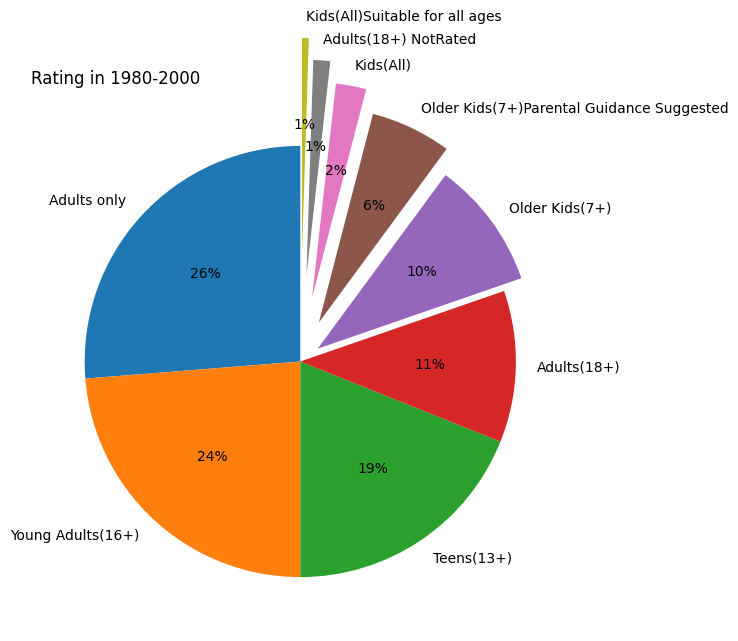

In [92]:
plt.figure(figsize=(7,7))
second.rating.value_counts().plot.pie(explode=(0,0,0,0,0.1,0.2,0.3,0.4,0.5),startangle=90,autopct='%.0f%%')
plt.title('Rating in 1980-2000',loc='left')
plt.show()

In [93]:
third=M[(M['release_year']>=2001)&(M['release_year']<=2021)]
third.reset_index(drop=True,inplace=True)
third.head() 

,index,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,Teens(13+),90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,Teens(13+),104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
2,6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,Older Kids(7+),91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
3,12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,Adults(18+),127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
4,13,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",United States,2021-09-22,2021,Older Kids(7+)Parental Guidance Suggested,91 min,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...


In [94]:
third.rating.value_counts()

rating
Adults(18+)                                        2003
Young Adults(16+)                                  1302
Adults only                                         678
Older Kids(7+)Parental Guidance Suggested           494
Teens(13+)                                          411
Older Kids(7+)                                      375
Kids(All)                                           154
Kids(All)Suitable for all ages                      122
Adults(18+) NotRated                                 68
Older Kids(7+)programming with fantasy violence       5
No One 17 and Under Admitted                          3
Unrated                                               2
Name: count, dtype: int64

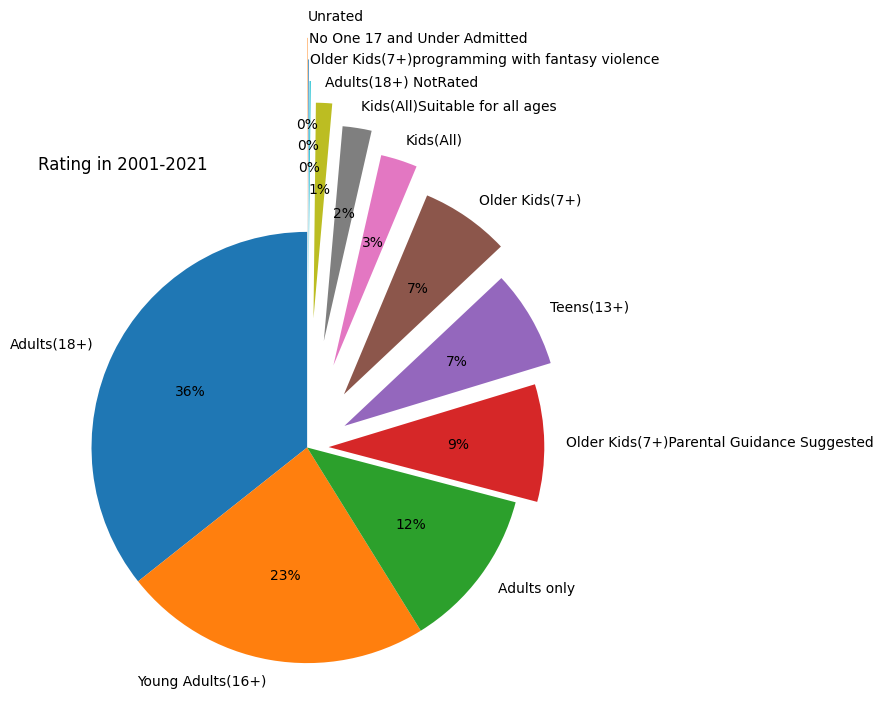

In [95]:
plt.figure(figsize=(7,7))
third.rating.value_counts().plot.pie(explode=(0,0,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9),startangle=90,autopct='%.0f%%')
plt.title('Rating in 2001-2021',loc='left')
plt.show()

# 10.Who is the actor who acted in more shows

In [96]:
dqr=data.assign(cast=data['cast'].str.split(',')).explode('cast')
dqr=dqr.reset_index(drop=True)
dqr.head()

,index,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,Teens(13+),90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,1,s2,TV Show,Blood & Water,Unknown,Ama Qamata,South Africa,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,1,s2,TV Show,Blood & Water,Unknown,Khosi Ngema,South Africa,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
3,1,s2,TV Show,Blood & Water,Unknown,Gail Mabalane,South Africa,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
4,1,s2,TV Show,Blood & Water,Unknown,Thabang Molaba,South Africa,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [97]:
dqr['cast']=dqr['cast'].str.lstrip()
dqr.dropna(subset=['cast'],inplace=True)
dqr.reset_index(drop=True,inplace=True)
dqr.head()

,index,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,Teens(13+),90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,1,s2,TV Show,Blood & Water,Unknown,Ama Qamata,South Africa,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,1,s2,TV Show,Blood & Water,Unknown,Khosi Ngema,South Africa,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
3,1,s2,TV Show,Blood & Water,Unknown,Gail Mabalane,South Africa,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
4,1,s2,TV Show,Blood & Water,Unknown,Thabang Molaba,South Africa,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [98]:
dqr.groupby('cast')['title'].count().sort_values(ascending=False)

cast
Unknown              825
Anupam Kher           43
Shah Rukh Khan        35
Julie Tejwani         33
Naseeruddin Shah      32
                    ... 
Şenay Bozoklar         1
Şenay Gürler           1
İpek Erdem             1
İpek Filiz Yazıcı      1
İsmail Filiz           1
Name: title, Length: 36429, dtype: int64

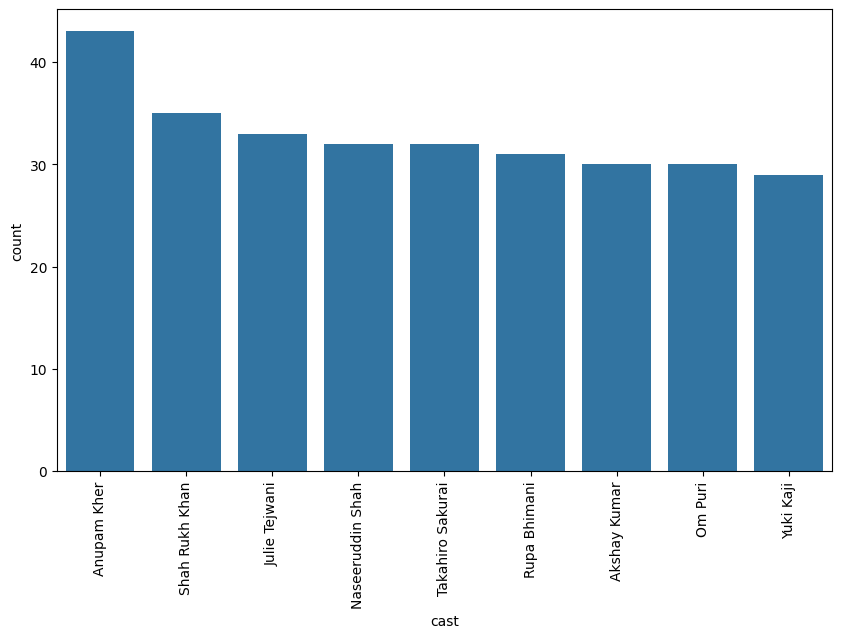

In [99]:
plt.figure(figsize=(10,6))
sns.countplot(x='cast',data=dqr,order=dqr['cast'].value_counts().index[1:10])
plt.xticks(rotation=90)
plt.show()

# 11.Which Month release more shows

In [100]:
data['month']=pd.DatetimeIndex(data['date_added']).month_name()
data.head()

,index,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month
0,0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,Teens(13+),90 min,Documentaries,"As her father nears the end of his life, filmm...",September
1,1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",September
2,2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,Adults(18+),1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,September
3,3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021-09-24,2021,Adults(18+),1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",September
4,4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Adults(18+),2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,September


In [101]:
mn=data.groupby('month')['title'].count().sort_values(ascending=False).to_frame().reset_index()
mn

,month,title
0,January,824
1,July,819
2,December,796
3,September,764
4,April,758
5,October,755
6,August,748
7,March,733
8,June,724
9,November,697


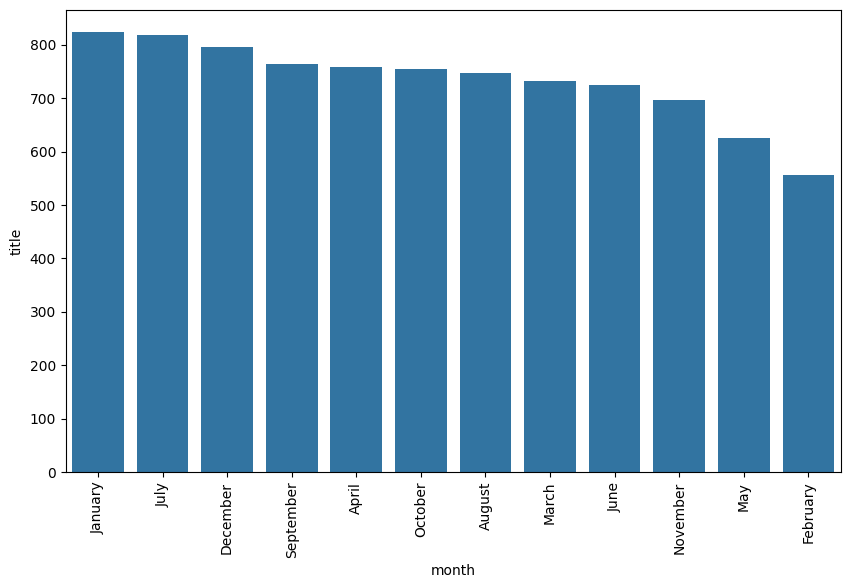

In [102]:
plt.figure(figsize=(10,6))
sns.barplot(x='month',y='title',data=mn)
plt.xticks(rotation=90)
plt.show()